In [ ]:
! pip install -q "datasets<4.0.0" transformers pytorch-crf seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 18.8 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import re
import unicodedata

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchcrf import CRF
from torch.nn.utils.rnn import pad_sequence
from transformers import (
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
)

from sklearn.metrics import f1_score  as f1_score_sklearn


from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [ ]:
from datasets import load_dataset

dataset = load_dataset("jakartaresearch/semeval-absa", "restaurant")

print(dataset)

README.md:   0%|          | 0.00/3.56k [00:00<?, ?B/s]

semeval-absa.py:   0%|          | 0.00/5.49k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/231k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3044 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/800 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'aspects', 'category'],
        num_rows: 3044
    })
    validation: Dataset({
        features: ['id', 'text', 'aspects', 'category'],
        num_rows: 800
    })
})


In [ ]:
dataset["train"][0]

{'id': '2339',
 'text': 'I charge it at night and skip taking the cord with me because of the good battery life.',
 'aspects': {'term': ['cord', 'battery life'],
  'polarity': ['neutral', 'positive'],
  'from': [41, 74],
  'to': [45, 86]}}

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

# EDA

In [ ]:
def get_all_lengths(example):
    lengths = []
    for aspect in example["aspects"]:
        if aspect["term"] != [""] and aspect["term"] != "":
            lengths.append(len(aspect["term"]))
        else:
            lengths.append(0)
    return {"length": lengths}

term_length = dataset.map(
    get_all_lengths,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/3048 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

## 1. Số lượng câu có thực thể và không có thực thể

In [ ]:
train_counts = pd.Series(term_length["train"]["length"])
val_counts = pd.Series(term_length["validation"]["length"])

has_term = sum(np.where(train_counts > 0, 1, 0))
no_term = sum(np.where(train_counts == 0, 1, 0))

print("- Số lượng có term trong train là: ", has_term)
print("- Số lượng không có term trong train là: ", no_term)

has_term = sum(np.where(val_counts > 0, 1, 0))
no_term = sum(np.where(val_counts == 0, 1, 0))

print("- Số lượng có term trong validation là: ", has_term)
print("- Số lượng không có term trong validation là: ", no_term)

- Số lượng có term trong train là:  1492
- Số lượng không có term trong train là:  1556
- Số lượng có term trong validation là:  422
- Số lượng không có term trong validation là:  378


## 2. Số lượng thực thể trong mỗi câu

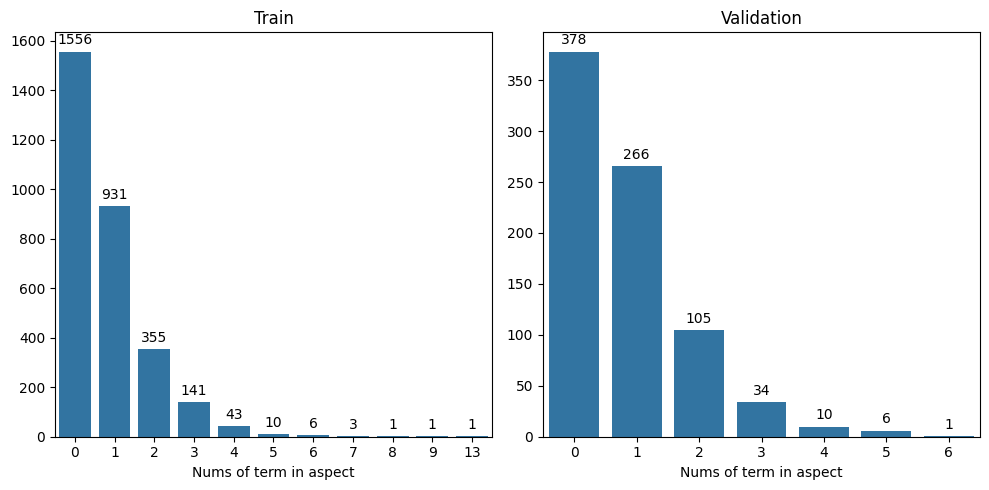

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10, 5))
train_vc = train_counts.value_counts().sort_index()
val_vc = val_counts.value_counts().sort_index()

sns.barplot(y=train_vc.values, x=train_vc.index.astype(str), ax=ax[0])
sns.barplot(y=val_vc.values, x=val_vc.index.astype(str), ax=ax[1])
ax[0].set_title("Train")
ax[1].set_title("Validation")
ax[0].set_xlabel("Nums of term in aspect")
ax[1].set_xlabel("Nums of term in aspect")

for axis in ax:
    for container in axis.containers:
        axis.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## Độ dài câu

In [ ]:
def get_length(text_list):
    return [len(tokenizer(text)["input_ids"]) for text in text_list]

length_dataset = dataset.map(
    lambda x: {"length" : get_length(x["text"])},
    batched=True,
    remove_columns=dataset["train"].column_names,
)

Map:   0%|          | 0/3048 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

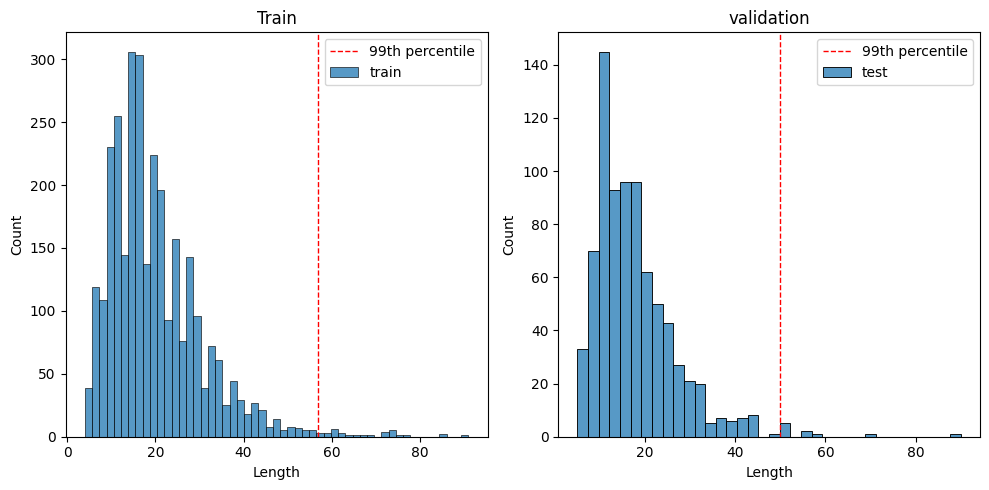

99th percentile train: 57.0
99th percentile test: 50.0
max length train: 91
max length test: 90


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

sns.histplot(length_dataset["train"]["length"], label="train", ax=ax[0])
ax[0].axvline(
    np.percentile(length_dataset["train"]["length"], 99),
    color="red", linestyle="--", linewidth=1, label="99th percentile"
)
ax[0].set_title("Train")
ax[0].set_xlabel("Length")
ax[0].legend(loc="upper right")

sns.histplot(length_dataset["validation"]["length"], label="test", ax=ax[1])
ax[1].axvline(
    np.percentile(length_dataset["validation"]["length"], 99),
    color="red", linestyle="--", linewidth=1, label="99th percentile"
)
ax[1].set_title("validation")
ax[1].set_xlabel("Length")
ax[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print(f"99th percentile train: {np.percentile(length_dataset['train']['length'], 99)}")
print(f"99th percentile test: {np.percentile(length_dataset['validation']['length'], 99)}")
print(f"max length train: {max(length_dataset['train']['length'])}")
print(f"max length test: {max(length_dataset['validation']['length'])}")

In [ ]:
# thống kê tỉ lệ các nhãn
def get_aspect_counter(example):
    entities = []
    for aspect in example["aspects"]:
        terms = aspect.get("term")
        polarities = aspect.get("polarity")
        for term, polarity in zip(terms, polarities):
            entities.append({
                "term": term,
                "polarity": polarity
            })
    return {"entities": entities}

aspect_counter = dataset.map(
    get_aspect_counter,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/3048 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

## Độ dài của aspects

In [ ]:
def get_aspect_length(batch):
    lengths = []
    entities = batch["entities"]
    num_examples = len(entities)

    for i in range(num_examples):
        tokens = len(tokenizer(entities[i]["term"])["input_ids"])
        lengths.append(tokens)

    return {"length": lengths}

aspect_length = aspect_counter.map(
    get_aspect_length,
    batched=True,
    remove_columns=aspect_counter["train"].column_names
)

Text(0.5, 0, 'Length')

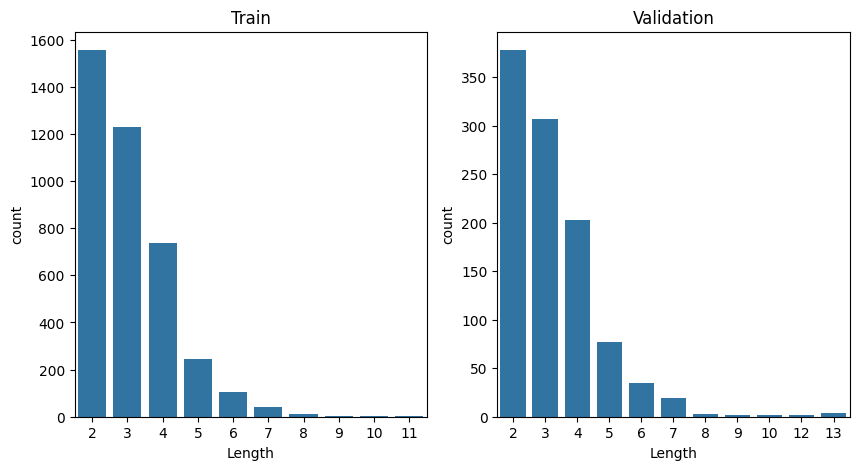

In [ ]:
fig , ax = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(x=aspect_length["train"]["length"], ax=ax[0])
ax[0].set_title("Train")
ax[0].set_xlabel("Length")

sns.countplot(x=aspect_length["validation"]["length"], ax=ax[1])
ax[1].set_title("Validation")
ax[1].set_xlabel("Length")

## Thống kê tỉ lệ các polarity

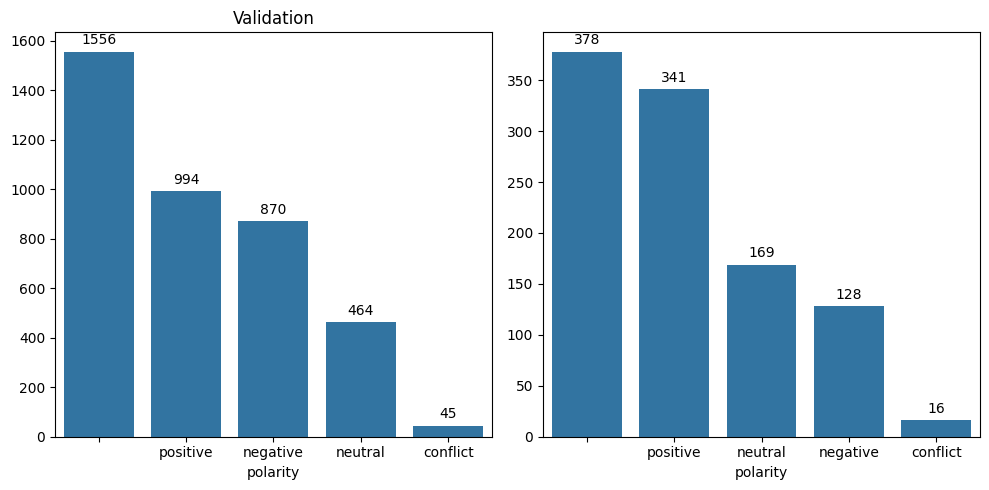

In [ ]:
train_df = pd.DataFrame(aspect_counter["train"]["entities"])
val_df = pd.DataFrame(aspect_counter["validation"]["entities"])

# Vẽ biểu đồ
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(x=train_df["polarity"].value_counts().index, y=train_df["polarity"].value_counts().values, ax=ax[0])
ax[0].set_title("Train")

sns.barplot(x=val_df["polarity"].value_counts().index, y=val_df["polarity"].value_counts().values, ax=ax[1])
ax[0].set_title("Validation")

for single_ax in ax:
    for container in single_ax.containers:
        single_ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## Thống kê Top các term

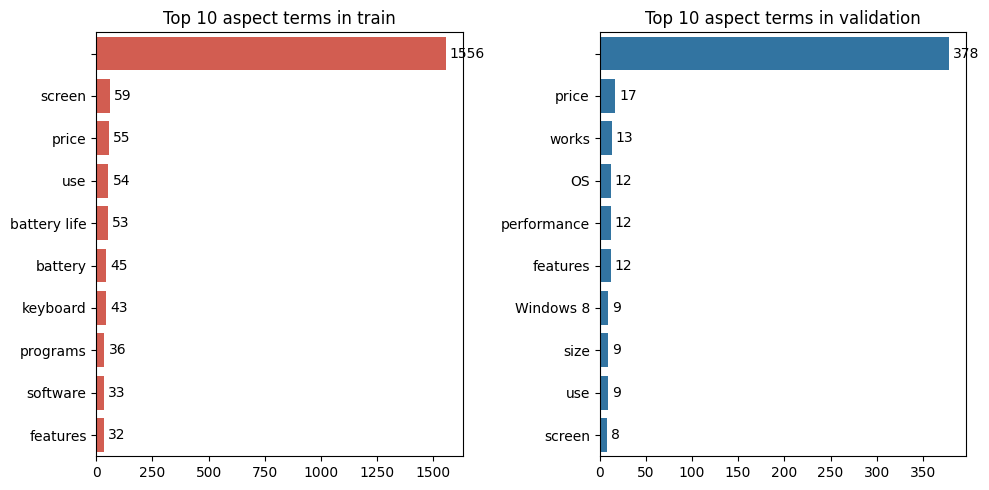

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(x=train_df['term'].value_counts().head(10).values, y=train_df['term'].value_counts().head(10).index, color="#e74c3c", ax=ax[0])
ax[0].set_title(f"Top 10 aspect terms in train")
ax[0].set_ylabel("")

sns.barplot(x=val_df['term'].value_counts().head(10).values, y=val_df['term'].value_counts().head(10).index, ax=ax[1])
ax[1].set_title(f"Top 10 aspect terms in validation")
ax[1].set_ylabel("")

for axis in ax:
    for container in axis.containers:
        axis.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

## Khía cạnh theo cảm xúc

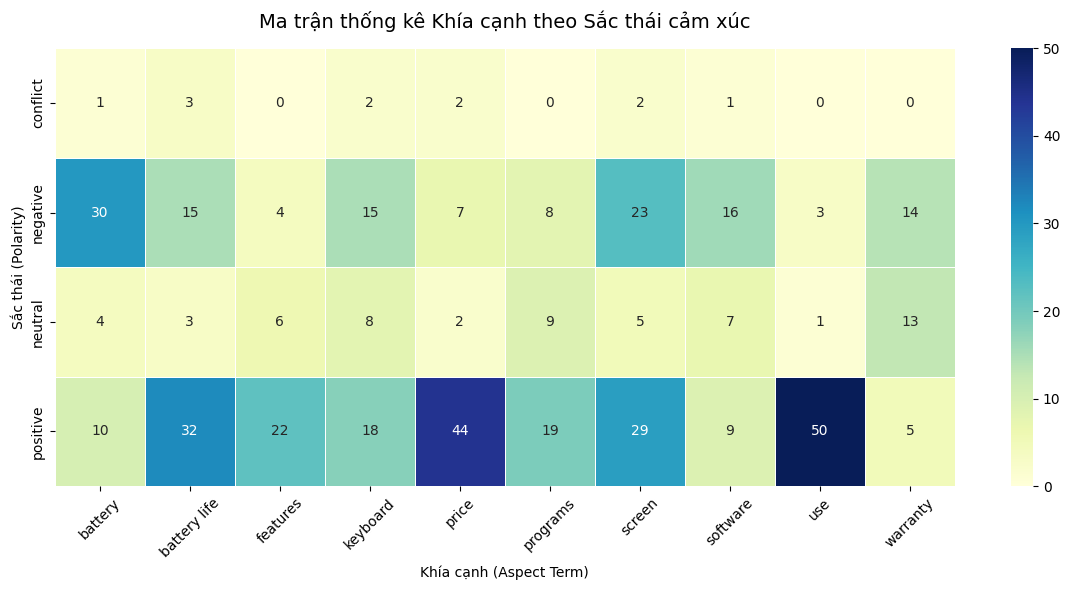

In [ ]:
top_10_term = train_df["term"].value_counts().index[1:11]
filtered_df = train_df[train_df["term"].isin(top_10_term)]

pivot_df = pd.crosstab(filtered_df["polarity"], filtered_df["term"])

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)

plt.title("Ma trận thống kê Khía cạnh theo Sắc thái cảm xúc", fontsize=14, pad=15)
plt.xlabel("Khía cạnh (Aspect Term)")
plt.ylabel("Sắc thái (Polarity)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Data Preprocessing

In [ ]:
def cleaned(batch):
    text_list = []

    for text in batch["text"]:
        cleaned_text = re.sub(r"/s+", " ", text).strip()
        text_list.append(cleaned_text)

    return {"text": text_list}

cleaned_dataset = dataset.map(cleaned, batched=True)

Map:   0%|          | 0/3048 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
tags = ["O", "B-ASP", "I-ASP"]
tags = sorted(tags)

idx2tag = {idx: tag for idx, tag in enumerate(tags)}
tag2idx = {tag: idx for idx, tag in enumerate(tags)}

print("Số lượng nhãn: ", len(tags))
print("Nhãn: ", idx2tag)

Số lượng nhãn:  3
Nhãn:  {0: 'B-ASP', 1: 'I-ASP', 2: 'O'}


# Step 1: Trích suất các khía cạnh

In [ ]:
aspect_labels = ["O", "B-ASP", "I-ASP"]
tag2id = {l: i for i, l in enumerate(aspect_labels)}
id2tag = {i: l for i, l in enumerate(aspect_labels)}

In [ ]:
def tokenize_and_align_labels(batch):
    tokenized_inputs = tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
        padding=False,
        return_offsets_mapping=True,
        add_special_tokens=False,
    )

    all_labels = []

    for i in range(len(batch["text"])):
        raw_text = batch["text"][i]
        offsets = tokenized_inputs["offset_mapping"][i]
        aspect_dict = batch["aspects"][i]

        start_spans = aspect_dict.get("from", [])
        end_spans = aspect_dict.get("to", [])

        # Sắp xếp các span theo thứ tự xuất hiện trong câu
        valid_spans = sorted(
            [(s, e) for s, e in zip(start_spans, end_spans) if s < e],
            key=lambda x: x[0]
        )

        label_ids = []
        current_active_span = None
        prev_token_end = 0

        seq_ids = tokenized_inputs.sequence_ids(batch_index=i)

        for idx, (off_start, off_end) in enumerate(offsets):
            # 1. Special tokens ([CLS], [SEP]) -> -100
            if seq_ids[idx] is None or off_start == off_end:
                label_ids.append(-100)
                continue

            # 2. Tìm aspect span bao trùm token
            matched_span = None
            for asp_start, asp_end in valid_spans:
                if max(off_start, asp_start) < min(off_end, asp_end):
                    matched_span = (asp_start, asp_end)
                    break

            # 3. Gán nhãn
            if matched_span is None:
                label_ids.append(tag2id["O"])
                current_active_span = None
            else:
                # TRƯỜNG HỢP A: Bắt đầu một aspect term mới
                if current_active_span != matched_span:
                    label_ids.append(tag2id["B-ASP"])
                    current_active_span = matched_span

                # TRƯỜNG HỢP B: Vẫn nằm trong cùng aspect term đó
                else:
                    # Kiểm tra xem đây có phải là TỪ MỚI hay không:
                    # - Có khoảng trắng trước token (BERT)
                    # - HOẶC token bắt đầu bằng ký tự khoảng trắng (RoBERTa/DeBERTa)
                    is_new_word = (off_start > prev_token_end) or (
                        off_start < len(raw_text) and raw_text[off_start].isspace()
                    )

                    if is_new_word:
                        label_ids.append(tag2id["I-ASP"])  # 'with', 'sausage', 'chicken'
                    else:
                        label_ids.append(-100)  # Subwords: 'rec', 'hie', 'te'

            prev_token_end = off_end

        all_labels.append(label_ids)

    tokenized_inputs["labels"] = all_labels
    tokenized_inputs.pop("offset_mapping")
    return tokenized_inputs

tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names
)

NameError: name 'cleaned_dataset' is not defined

In [ ]:
class AspectExtractor(nn.Module):
    def __init__(self, vocab_size, embedding_size, hidden_dim, output_dim, dropout, tag2idx):
        super().__init__()
        self.tag2idx = tag2idx
        self.idx2tag = {v: k for k, v in tag2idx.items()}

        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.lstm = nn.LSTM(
            embedding_size, hidden_dim // 2,
            num_layers=1, bidirectional=True, batch_first=True
        )
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.attention = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

        # CRF Layer
        self.crf = CRF(output_dim, batch_first=True)

    def forward(self, input_ids, attention_mask=None, labels=None):
        # Feature Extraction
        embedded = self.dropout(self.embedding(input_ids))
        lstm_out, _ = self.lstm(embedded)
        lstm_out = self.dropout(self.layer_norm(lstm_out))

        # Attention đơn giản
        att_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = lstm_out * att_weights + lstm_out
        emissions = self.fc(self.dropout(context))

        loss = None
        if labels is not None:
            crf_mask = (labels != -100).bool()
            clean_labels = torch.where(labels != -100, labels, torch.zeros_like(labels))
            log_likelihood = self.crf(emissions, clean_labels, mask=crf_mask, reduction='token_mean')
            loss = -log_likelihood

        return {
            "loss": loss,
            "logits": emissions,
        }

In [ ]:
class CRFTrainer(Trainer):

    def prediction_step(self, model, inputs, prediction_loss_only=False, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)

        with torch.no_grad():
            outputs = model(**inputs)
            loss = outputs.get("loss")

            if prediction_loss_only:
                return (loss, None, None)

            # Lấy emissions từ model
            emissions = outputs.get("logits")
            labels = inputs.get("labels")

            # 1. Xác định Mask chuẩn:
            # Ưu tiên lấy theo labels != -100 để khớp hoàn toàn với lúc train
            if labels is not None:
                mask = (labels != -100).bool()
            elif inputs.get("attention_mask") is not None:
                mask = inputs.get("attention_mask").bool()
            else:
                mask = None

            # 2. Xử lý trường hợp model bị bọc bởi DataParallel
            crf_layer = model.module.crf if hasattr(model, "module") else model.crf

            # 3. CRF Decode
            best_paths = crf_layer.decode(emissions, mask=mask)

            # 4. Tạo tensor có shape GIỐNG HỆT labels/input_ids và fill sẵn -100
            # Giúp đảm bảo: Không lệch shape giữa các batch & Giữ đúng vị trí token
            ref_tensor = labels if labels is not None else inputs.get("input_ids")
            padded_predictions = torch.full_like(ref_tensor, fill_value=-100, dtype=torch.long)

            # 5. Điền kết quả decode vào ĐÚNG các vị trí mask là True
            for i, path in enumerate(best_paths):
                if mask is not None:
                    # Lấy các index thực tế của mask dòng thứ i
                    true_indices = torch.nonzero(mask[i], as_tuple=False).squeeze(-1)
                    padded_predictions[i, true_indices] = torch.tensor(
                        path, device=ref_tensor.device, dtype=torch.long
                    )
                else:
                    padded_predictions[i, :len(path)] = torch.tensor(
                        path, device=ref_tensor.device, dtype=torch.long
                    )

        return (loss, padded_predictions, labels)

In [ ]:
def compute_metrics(eval_preds):
    predictions, labels = eval_preds

    true_predictions = [
        [idx2tag[int(p)] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [idx2tag[int(l)] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    return {
        "f1": f1_score(true_labels, true_predictions),
    }

In [ ]:
model = AspectExtractor(
    vocab_size=tokenizer.vocab_size,
    embedding_size=128,
    hidden_dim=256,
    output_dim=3,
    dropout=0.2,
    tag2idx=tag2idx
)

In [ ]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=-100
)

In [ ]:
# Split train-test
train_val_dataset = tokenized_dataset["train"].train_test_split(test_size=0.2, seed=42)
train_dataset = train_val_dataset["train"]
eval_dataset = train_val_dataset["test"]
test_dataset =  tokenized_dataset["train"]

In [ ]:
training_args = TrainingArguments(
    output_dir='/content/lstm_extractor',
    num_train_epochs=50,
    learning_rate=5e-4,
    weight_decay=0.01,
    max_grad_norm=1.0,
    warmup_steps = 50,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True
)

trainer = CRFTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

In [ ]:
train_result = trainer.train()
print('Train result:', train_result)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1
1,0.842992,0.308622,0.008147
2,0.274070,0.213345,0.144538


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

# Step 2: Xác định polarity của các aspect

In [ ]:
labels = ["negative", "neutral", "positive", "conflict"]
labels = sorted(labels)

idx2label = {idx: label for idx, label in enumerate(labels)}
label2idx = {label: idx for idx, label in enumerate(labels)}

print("Số lượng nhãn: ", len(labels))
print("Nhãn: ", idx2label)

Số lượng nhãn:  4
Nhãn:  {0: 'conflict', 1: 'negative', 2: 'neutral', 3: 'positive'}


In [ ]:
def prepare_for_sentiment(batch):
    batch_texts = []
    batch_terms = []
    batch_polarities = []

    texts = batch.get("text")
    aspects = batch.get("aspects")
    num_examples = len(texts)

    for i in range(num_examples):
        aspect = aspects[i]
        text_ids = tokenizer.encode(texts[i], truncation=True, max_length=64, add_special_tokens=False)
        terms = aspect.get("term", [])
        polarities = aspect.get("polarity", [])

        for term, polarity in zip(terms, polarities):
            if term == "" or polarity not in label2idx:
                continue

            term_ids = tokenizer.encode(term, truncation=True, max_length=16, add_special_tokens=False)

            batch_texts.append(text_ids)
            batch_terms.append(term_ids)
            batch_polarities.append(label2idx[polarity])

    return {
        "text_ids": batch_texts,
        "aspect_ids": batch_terms,
        "label": batch_polarities
    }

tokenized_dataset = cleaned_dataset.map(
    prepare_for_sentiment,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/3048 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
# Split train-test
train_val_dataset = tokenized_dataset["train"].train_test_split(test_size=0.2, seed=42)
train_dataset = train_val_dataset["train"]
eval_dataset = train_val_dataset["test"]
test_dataset =  tokenized_dataset["train"]

In [ ]:
class ABSADataCollator:
    def __init__(self, pad_token_id=0):
        self.pad_token_id = pad_token_id

    def __call__(self, batch):

        text_ids = [torch.tensor(item['text_ids'], dtype=torch.long) for item in batch]
        aspect_ids = [torch.tensor(item['aspect_ids'], dtype=torch.long) for item in batch]

        text_padded = pad_sequence(text_ids, batch_first=True, padding_value=self.pad_token_id)
        aspect_padded = pad_sequence(aspect_ids, batch_first=True, padding_value=self.pad_token_id)
        text_mask = (text_padded != self.pad_token_id)

        batch_dict = {
            "text_ids": text_padded,
            "aspect_ids": aspect_padded,
            "text_mask": text_mask,
        }

        if 'label' in batch[0]:
            batch_dict["labels"] = torch.tensor([item['label'] for item in batch], dtype=torch.long)

        return batch_dict

In [ ]:
class SentinentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_size, hidden_dim, output_dim, dropout, num_heads=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.aspect_proj = nn.Linear(embedding_size, hidden_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(hidden_dim)

        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, text_ids, aspect_ids, text_mask=None, labels=None):
        text_emb = self.dropout(self.embedding(text_ids))
        lstm_out, _ = self.lstm(text_emb) # (batch, seq, hidden_dim)

        aspect_emb = self.dropout(self.embedding(aspect_ids))
        aspect_query = self.aspect_proj(aspect_emb) # (batch, aspect_len, hidden_dim)


        text_emb = self.dropout(text_emb)
        aspect_emb = self.dropout(aspect_emb)

        key_padding_mask = ~text_mask if text_mask is not None else None
        attn_output, _ = self.attention(
            query=aspect_query,
            key=lstm_out,
            value=lstm_out,
            key_padding_mask=key_padding_mask
        )

        context = self.layer_norm(attn_output + aspect_query) # (batch, seq, hidden_dim)

        # Pooling
        context_vec = context.mean(dim=1)        # (batch_size, hidden_dim)
        aspect_vec = aspect_query.mean(dim=1)    # (batch_size, hidden_dim)

        features = torch.cat([context_vec, aspect_vec], dim=-1)  # (batch_size, hidden_dim * 2)
        logits = self.fc(self.dropout(features))                 # (batch_size, num_classes)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {
            "loss": loss,
            "logits": logits,
        }

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.argmax(predictions, axis=1)

    return {
        "f1": f1_score_sklearn(labels, predictions, average="macro"),
    }

In [ ]:
model = SentinentLSTM(
    vocab_size=len(tokenizer),
    embedding_size=128,
    hidden_dim=256,
    output_dim=len(labels),
    dropout=0.2,
    num_heads=8
)

In [ ]:
pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

training_args = TrainingArguments(
    output_dir='/content/lstm_sentinent',
    num_train_epochs=50,
    learning_rate=5e-4,
    weight_decay=0.01,
    max_grad_norm=1.0,
    warmup_steps = 50,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=3,

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True
)

data_collator = ABSADataCollator(pad_token_id=pad_token_id)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

In [ ]:
# Bắt đầu huấn luyện
trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1
1,1.312538,1.140632,0.201916
2,1.089317,1.001349,0.328329


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 